In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist

print(f"Running on PyMC3 v{pm.__version__}")

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


Running on PyMC3 v3.11.5


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_bt_dem.csv").dropna()
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)

In [6]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()


In [7]:
hr_bt_capsx= pm.Model(coords=coords) 

with hr_bt_capsx:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_dtd, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_dtd)
    
    mu_b_capsx = pm.Normal("mu_b_capsx", mu=0.0, sigma=0.5)
    sigma_b_capsx = pm.HalfNormal("sigma_b_capsx", 0.5)
    mu_b = pm.Normal("mu_b", mu=0, sigma=100)
    sigma_b = pm.HalfNormal("sigma_b", 5)
    mu_b_caps = pm.Normal("mu_b_caps", mu=0.0, sigma=0.5)
    sigma_b_caps = pm.HalfNormal("sigma_b_caps", 0.5)
    
    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b_capsx = pm.Normal("b_capsx", mu=mu_b_capsx, sigma=sigma_b_capsx, dims="participant")
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")
    b_caps = pm.Normal("b_caps", mu=mu_b_caps, sigma=sigma_b_caps, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    draws_est_capsx = a[participant_idx]+b[participant_idx]* data.session.values+b_caps[participant_idx] * data.caps.values+b_capsx[participant_idx] * data.caps.values* data.session.values

    # Data likelihood
    draws_like_capsx = pm.Normal(
        "draws_like_capsx", mu=draws_est_capsx, sigma=eps, observed=data.draws, dims="obs_id"
    )
    
    

In [8]:
with hr_bt_capsx:
    hr_bt_trace_capsx = pm.sample(5000,tune=5000, target_accept=0.99, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b_caps, b, b_capsx, a, sigma_b_caps, mu_b_caps, sigma_b, mu_b, sigma_b_capsx, mu_b_capsx, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 3174 seconds.


0, dim: obs_id, 1357 =? 1357


There were 1314 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.8305469797773152, but should be close to 0.99. Try to increase the number of tuning steps.
There were 11 divergences after tuning. Increase `target_accept` or reparameterize.
The chain reached the maximum tree depth. Increase max_treedepth, increase target_accept or reparameterize.
There were 106 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.971192811095552, but should be close to 0.99. Try to increase the number of tuning steps.
There were 65 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.9687807705277255, but should be close to 0.99. Try to increase the number of tuning steps.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems duri

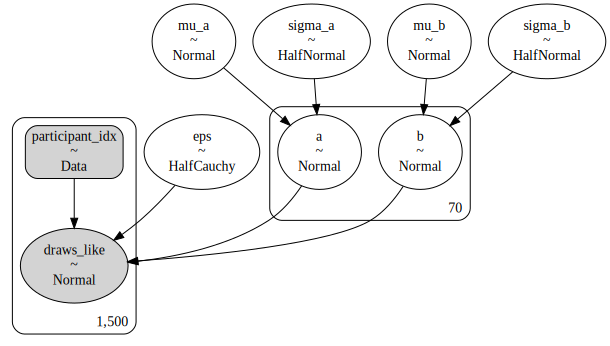

In [9]:
pm.model_to_graphviz(hr_bt_capsx)

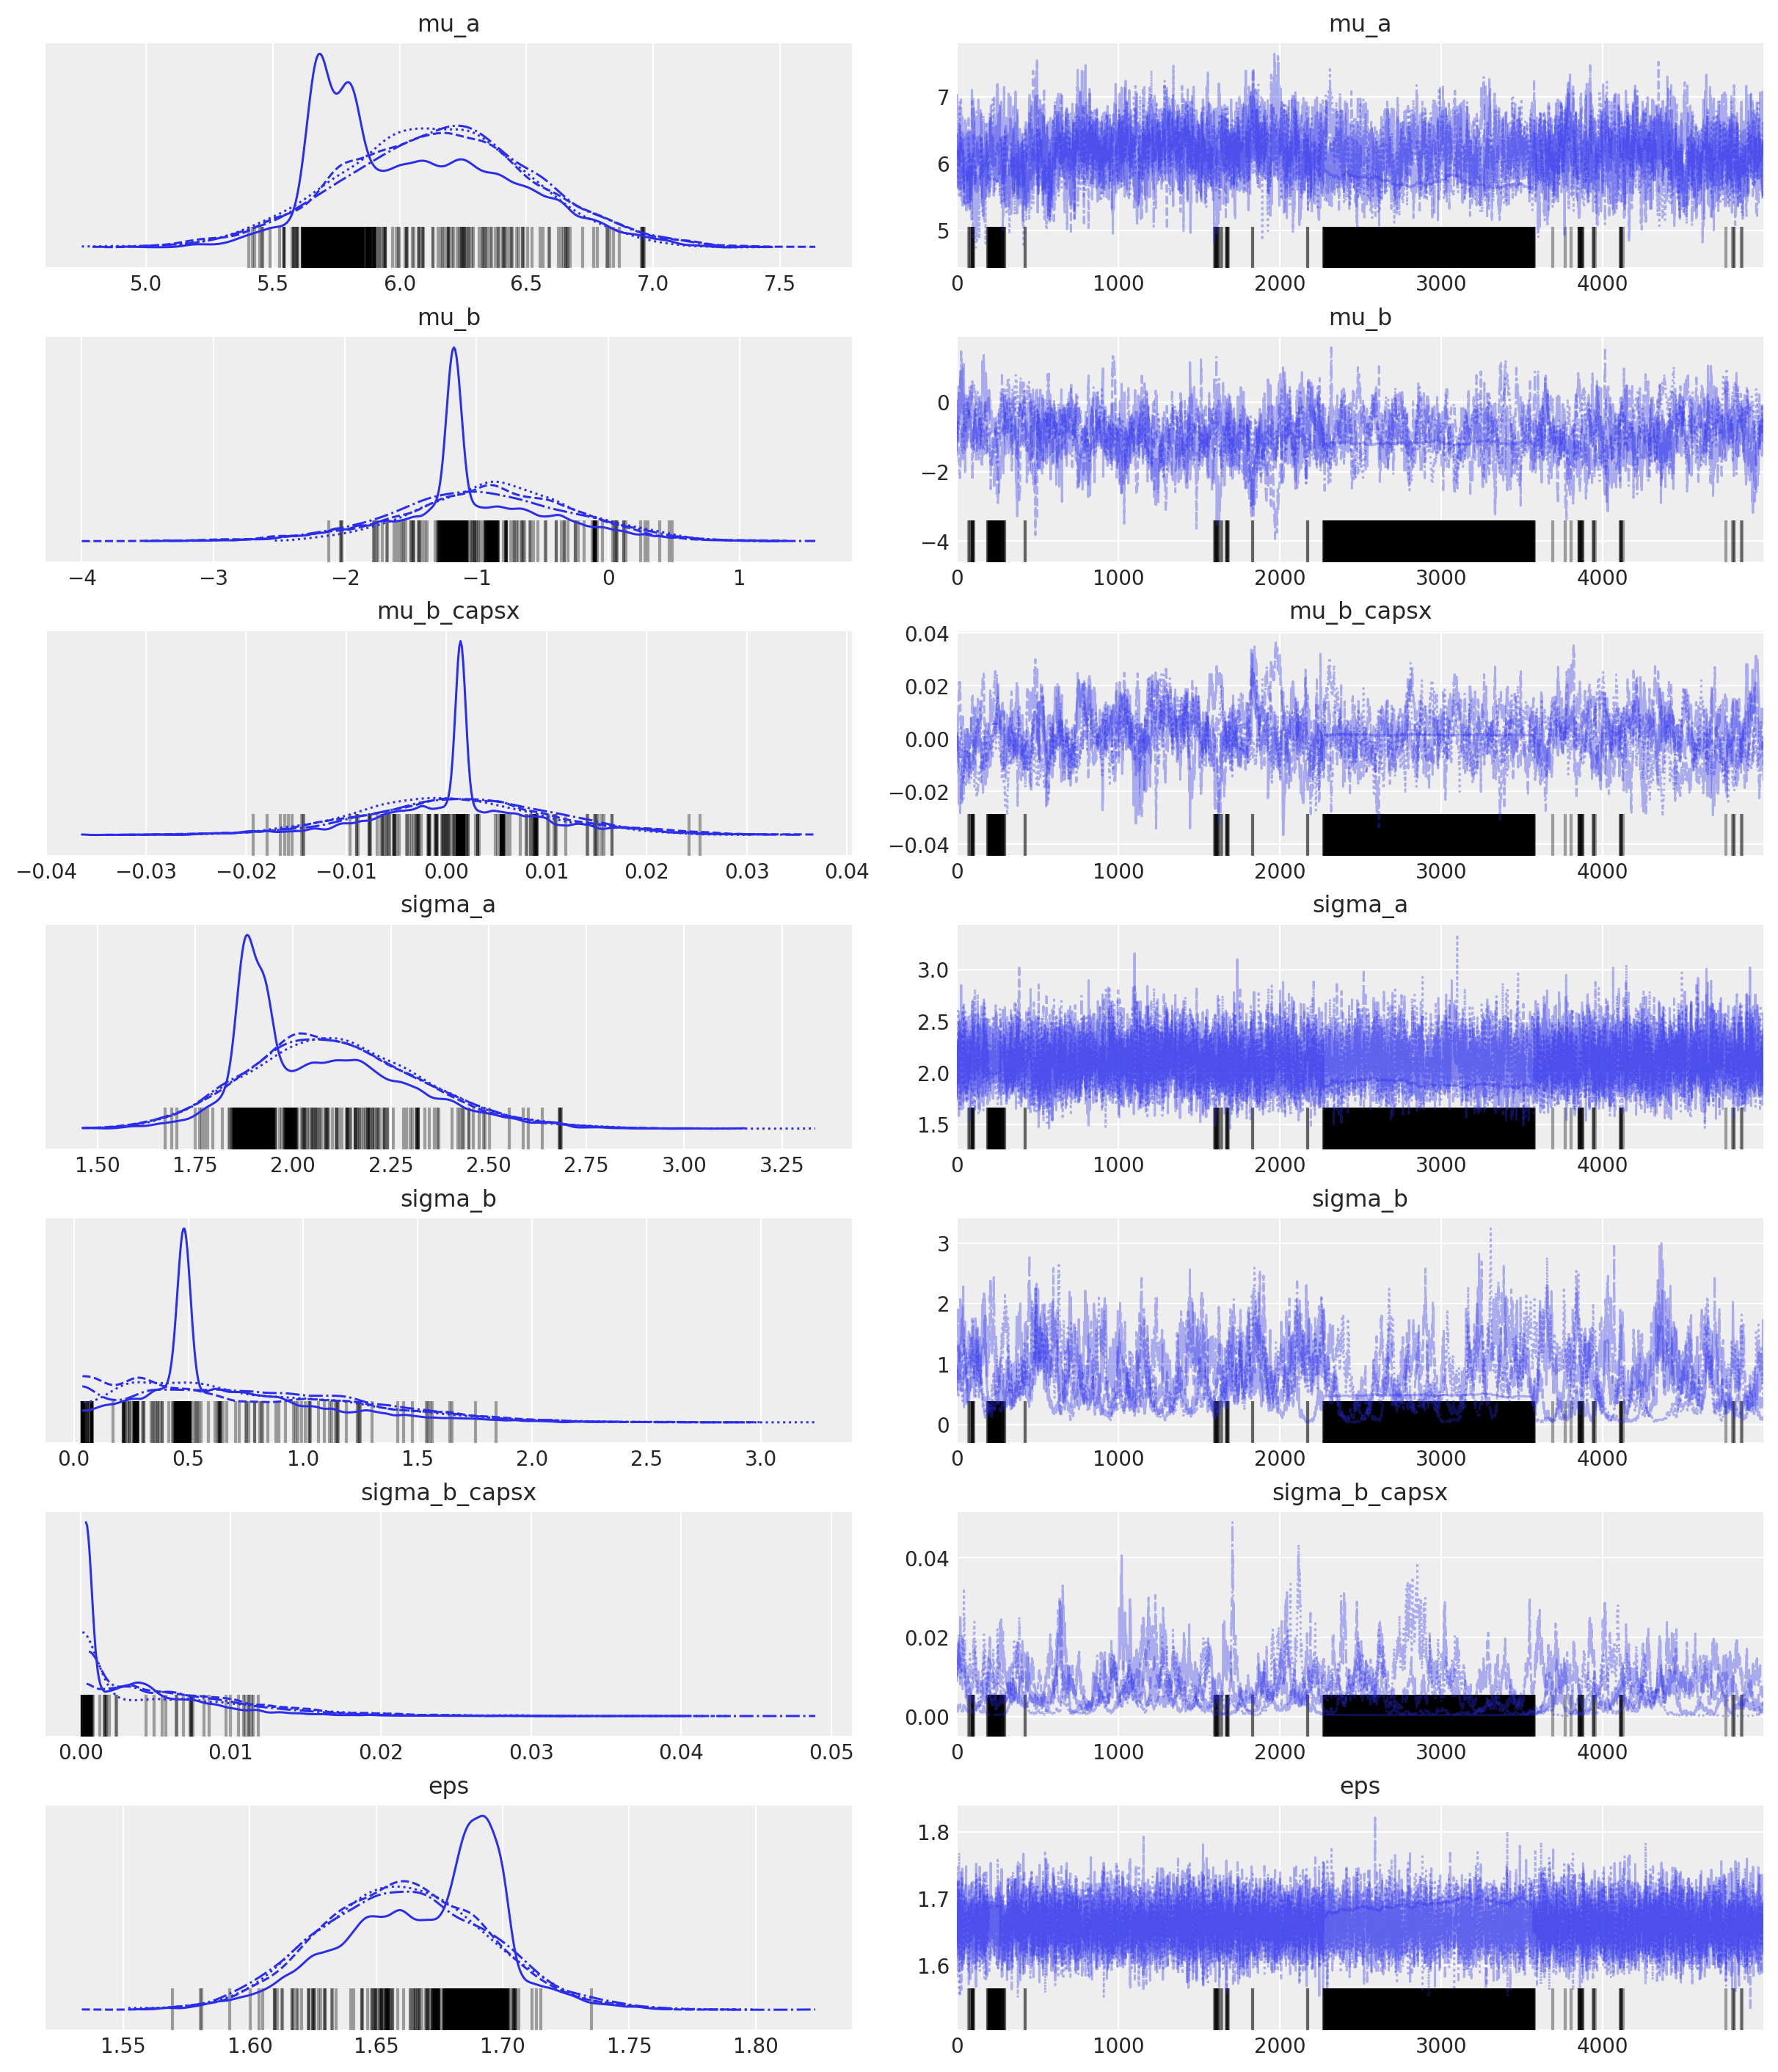

In [10]:
az.plot_trace(hr_bt_trace_capsx, var_names=["mu_a", "mu_b","mu_b_capsx",  "sigma_a", "sigma_b", "sigma_b_capsx","eps"]);

In [9]:
stat_tms_reg_capsx=pm.summary(hr_bt_trace_capsx)
stat_tms_reg_capsx


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.124,0.384,5.436,6.849,0.026,0.019,213.0,2054.0,1.02
mu_b_capsx,0.001,0.009,-0.017,0.019,0.000,0.000,384.0,795.0,1.06
mu_b,-0.935,0.655,-2.200,0.302,0.033,0.024,373.0,1047.0,1.02
mu_b_caps,0.003,0.007,-0.010,0.015,0.000,0.000,262.0,656.0,1.01
a[0],5.116,1.462,2.497,7.954,0.080,0.063,381.0,5587.0,1.01
...,...,...,...,...,...,...,...,...,...
sigma_a,2.096,0.219,1.733,2.543,0.011,0.008,419.0,7072.0,1.01
sigma_b_capsx,0.006,0.005,0.000,0.016,0.001,0.000,28.0,27.0,1.11
sigma_b,0.739,0.474,0.035,1.586,0.035,0.025,192.0,226.0,1.02
sigma_b_caps,0.005,0.004,0.000,0.012,0.000,0.000,109.0,60.0,1.03


In [75]:
b_mu_reg_capsx=stat_tms_reg_capsx.loc['mu_b_capsx']['mean']
b_sigma_reg_capsx=stat_tms_reg_capsx.loc['mu_b_capsx']['sd']

In [76]:
print ("Beta PDI =/0") 
b_capsx=NormalDist(mu=b_mu_reg_capsx, sigma=b_sigma_reg_capsx).overlap(NormalDist(mu=0, sigma=b_sigma_reg_capsx))
print (b_capsx)

Beta TMS =/0
0.5639914206179697


In [32]:
with hr_bt_capsx:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace_capsx, var_names=["a","b_pdix","draws_like"]
    )

<AxesSubplot:xlabel='draws_like / draws_like'>

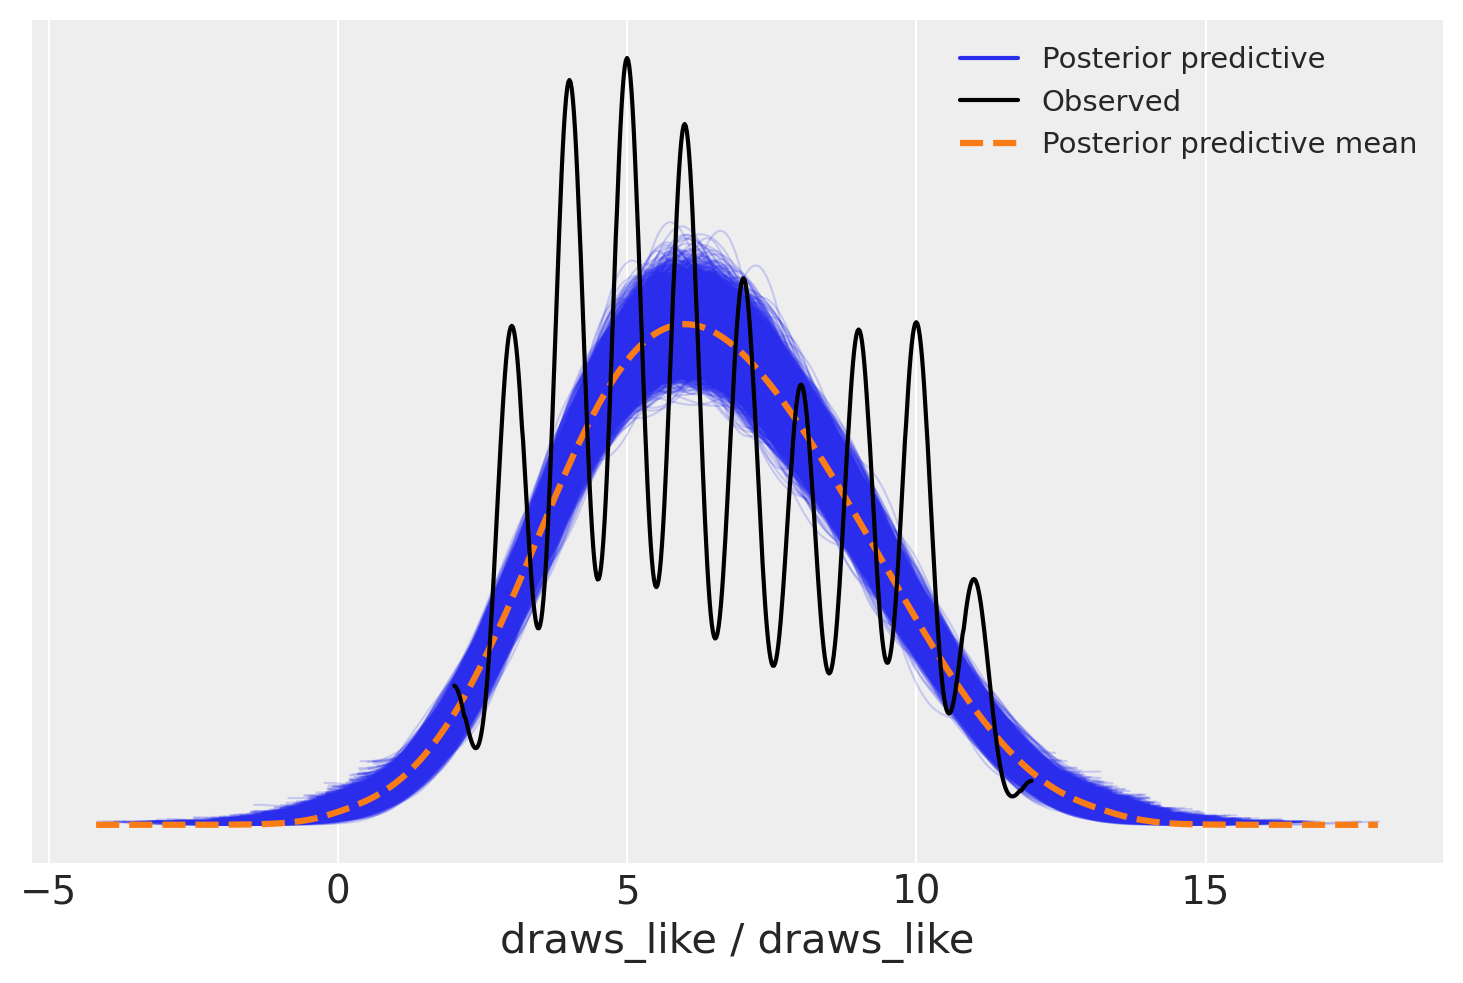

In [33]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt_capsx))

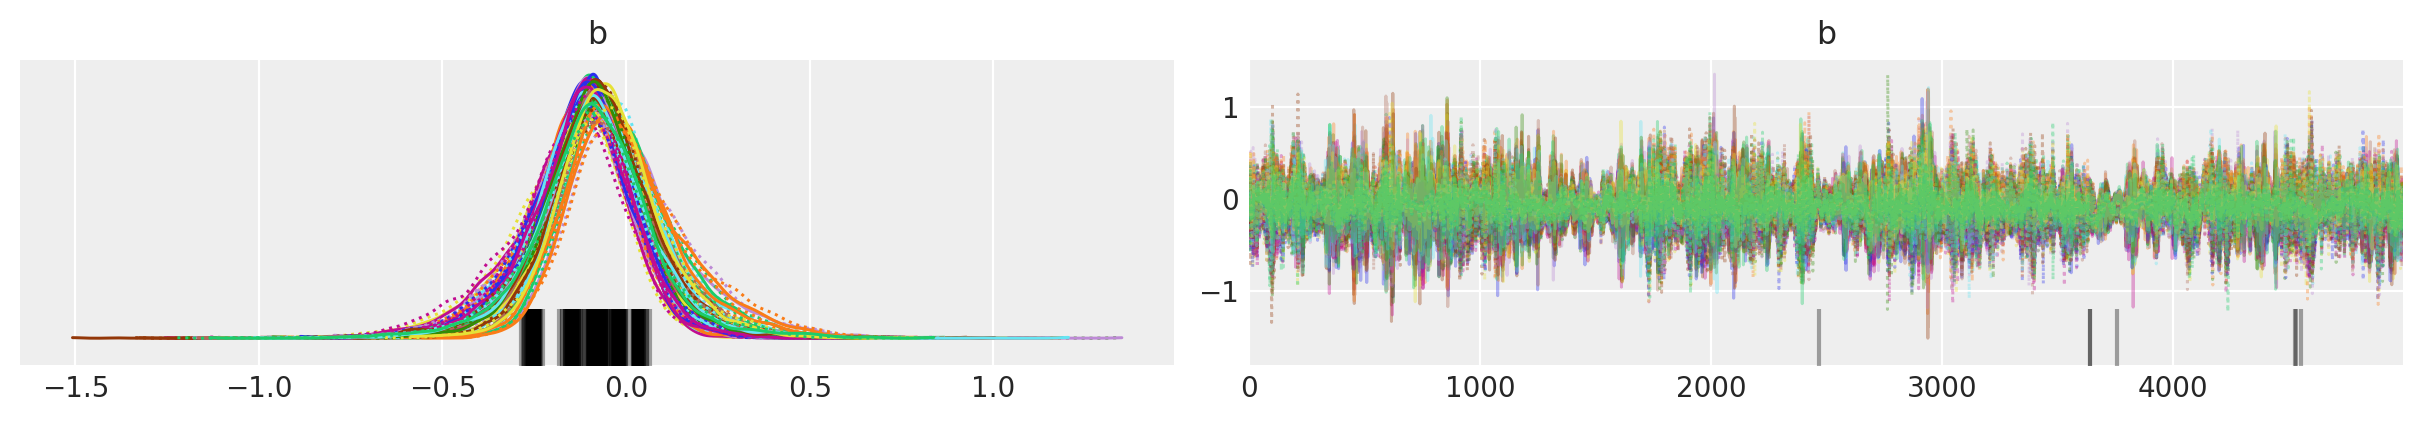

In [34]:
az.plot_trace(hr_bt_trace_capsx, var_names=["b_capsx"], coords={"participant": participant});
